In [2]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import proplot as pplt
from IPython.display import display
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']
WEIGHTSDIR = CONFIGS['filepaths']['weights']
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
FIELDVARS  = CONFIGS['experiments']['nn']['runs']['nn_gauss']['fieldvars']
SEEDS      = CONFIGS['experiments']['nn']['seeds']
EQUATIONS  = CONFIGS['experiments']['sr']['optimizedeqs']
REFNAME    = 'nn_gauss'
MODELINFO  = {**{name:(eq['description'],eq['color'],'-') for name,eq in EQUATIONS.items()},
              REFNAME:(CONFIGS['experiments']['nn']['runs'][REFNAME]['description'],'gray','--')}
OBSINFO    = {'era5':('ERA5',dict(color='k',marker='o',markersize=3,linestyle='none')),
              'imerg':('IMERG',dict(color='k',marker='s',markersize=3,markerfacecolor='none',linestyle='none'))}
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'test'
LANDFRAC   = 0.5
NHOURBINS  = 8
TABLEMODELS = ['sr_atm_eq','sr_sfc_eq','sr_all_eq','sr_all_pc_eq']
REGIONS    = {'Ocean':'#539ED4','Land':'#D42028'}
REGISTRY   = {row['name']:json.loads(row['constants']) for _,row in pd.read_csv(os.path.join(MODELSDIR,'sr','optimized_equations.csv')).iterrows()}

In [4]:
def kernel_integrate(fields,weights,dsig):
    return (fields*weights[None,:,:]*dsig[None,None,:]).sum(axis=2)

def to_precip(exponent):
    return np.maximum(np.expm1(exponent),0.0)

def get_prediction_path(name):
    return os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')

def load_prediction(name):
    with xr.open_dataset(get_prediction_path(name)) as ds:
        da = ds['tp'].load()
    if 'seed' in da.dims:
        da = da.mean('seed')
    return da.squeeze().transpose('time','lat','lon').values.ravel()

def calc_r2(pred,target,mask):
    return 1-np.sum((pred[mask]-target[mask])**2)/np.sum((target[mask]-target[mask].mean())**2)

def format_bin(hour,width=24/NHOURBINS):
    start = int(hour-width/2)
    return f'{start:02d}--{start+int(width):02d}'

def get_label(name):
    return OBSINFO[name][0] if name in OBSINFO else MODELINFO[name][0]

def calc_local_hour_bin(hours,lon,shape,nbins=NHOURBINS):
    localhour = (hours[:,None,None]+lon[None,None,:]/15.0)%24
    return (np.broadcast_to(localhour,shape).ravel()//(24/nbins)).astype(int)

def bin_by_hour(hourbin,z,mask,nbins=NHOURBINS):
    counts = np.bincount(hourbin[mask],minlength=nbins)
    sums   = np.bincount(hourbin[mask],weights=z[mask],minlength=nbins)
    return sums/np.maximum(counts,1)

def calc_grid_composite(z,hourbin,mask,shape,nbins=NHOURBINS):
    ngrid     = shape[1]*shape[2]
    gridindex = np.broadcast_to(np.arange(ngrid),(shape[0],ngrid)).ravel()
    index     = hourbin[mask]*ngrid+gridindex[mask]
    counts    = np.bincount(index,minlength=nbins*ngrid).reshape(nbins,ngrid)
    sums      = np.bincount(index,weights=z[mask],minlength=nbins*ngrid).reshape(nbins,ngrid)
    return np.where(counts>0,sums/np.maximum(counts,1),np.nan)

def calc_peak_bin(composite):
    filled = np.where(np.isfinite(composite),composite,-np.inf)
    valid  = np.isfinite(composite).all(axis=0)&(filled.max(axis=0)>0)
    return np.where(valid,filled.argmax(axis=0),np.nan)

def calc_bin_distance(a,b,nbins=NHOURBINS):
    distance = np.abs(a-b)%nbins
    return np.minimum(distance,nbins-distance)

def format_map(ax,title):
    ax.format(title=title,coast=True,lonlim=LONRANGE,lonlines=[65,75,85],lonlabels='b',latlim=LATRANGE,latlines=[10,15,20],latlabels='l',grid=False)

In [5]:
with open(os.path.join(SPLITSDIR,'stats.json'),'r',encoding='utf-8') as f:
    STATS = json.load(f)
atm,sfc,pc = (REGISTRY[name] for name in ['sr_atm_eq','sr_sfc_eq','sr_all_pc_eq'])

lam        = STATS['tp_std']*atm['c3']/STATS['thetae_std']**3
gamma      = atm['c4']*STATS['thetae_std']/STATS['thetaestar_std']
thetac     = STATS['thetae_mean']-gamma*STATS['thetaestar_mean']+atm['c5']*STATS['thetae_std']
kappa      = STATS['thetae_std']/STATS['rh_std']
rhmean     = STATS['rh_mean']
thetaemean = STATS['thetae_mean']
shfmean    = STATS['shf_mean']
lhfmean    = STATS['lhf_mean']

lamshfsfc  = STATS['tp_std']*sfc['c6']/STATS['shf_std']
lfcsfc     = sfc['c7']
lamlhfsfc  = STATS['tp_std']*sfc['c8']/STATS['lhf_std']

lamthetae  = STATS['tp_std']/STATS['thetae_std']
lamshfpc   = STATS['tp_std']*pc['c12']/STATS['shf_std']
lfcpc      = pc['c13']
betapc     = STATS['tp_std']*pc['c14']

In [6]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    ntime,nlat,nlon = (ds.sizes[dim] for dim in ['time','lat','lon'])
    lat,lon,dsig    = ds['lat'].values,ds['lon'].values,ds['dsig'].values
    hours      = ds['time'].dt.hour.values
    fields     = np.stack([ds[name].transpose('time','lat','lon','sig').values.reshape(-1,dsig.size) for name in FIELDVARS],axis=1)
    tp,pr,shf,lhf = (ds[name].transpose('time','lat','lon').values.ravel() for name in ['tp','pr','shf','lhf'])
    lf         = xr.broadcast(ds['lf'],ds['tp'])[0].transpose('time','lat','lon').values.ravel()

kernels = []
for seed in SEEDS:
    with xr.open_dataset(os.path.join(WEIGHTSDIR,f'nn_gauss_{seed}_weights.nc'),engine='h5netcdf') as ds:
        kernels.append(ds['k'].values)
integrals   = dict(zip(FIELDVARS,kernel_integrate(fields,np.mean(kernels,axis=0),dsig).T))
moisture    = kappa*(integrals['rh']-rhmean)
instability = integrals['thetae']-gamma*integrals['thetaestar']-thetac
atmexp      = lam*np.maximum(moisture,instability)**3
surface     = lamshfsfc*(lfcsfc-lf)*(shf-shfmean)+lamlhfsfc*(lhf-lhfmean)
correction  = lamthetae*((lfcpc-lf)**3+(1-lfcpc)**3)*(integrals['thetae']-thetaemean)+lamshfpc*(lfcpc-lf)**3*(shf-shfmean)-betapc

obstp  = {'era5':tp,'imerg':3.0*pr}
predtp = {name:load_prediction(name) for name in MODELINFO if os.path.exists(get_prediction_path(name))}
print(f"Loaded predictions: {', '.join(MODELINFO[name][0] for name in predtp)}")
finite = np.isfinite(moisture)&np.isfinite(instability)&np.isfinite(surface)&np.isfinite(correction)
for values in [*obstp.values(),*predtp.values()]:
    finite &= np.isfinite(values)
for name,exponent in [('sr_atm_eq',atmexp),('sr_sfc_eq',atmexp+surface),('sr_all_pc_eq',atmexp+correction)]:
    print(f"Max difference from saved {MODELINFO[name][0]} predictions: {np.nanmax(np.abs(to_precip(exponent)[finite]-predtp[name][finite])):.2e} mm")

shape       = (ntime,nlat,nlon)
hourbin     = calc_local_hour_bin(hours,lon,shape)
hourcenters = (np.arange(NHOURBINS)+0.5)*24/NHOURBINS
regionmasks = {'Ocean':finite&(lf<LANDFRAC),'Land':finite&(lf>=LANDFRAC)}
lfgrid      = lf.reshape(shape)[0].ravel()
gridmasks   = {'Ocean':lfgrid<LANDFRAC,'Land':lfgrid>=LANDFRAC}
alltp       = {**obstp,**predtp}
composites  = {name:calc_grid_composite(values,hourbin,finite,shape) for name,values in alltp.items()}
peakbins    = {name:calc_peak_bin(composite) for name,composite in composites.items()}

Loaded predictions: SR-BL, SR-ATM, SR-SFC, SR-ALL, SR-ALL-PC, NN-GAUSS
Max difference from saved SR-ATM predictions: 8.53e-02 mm
Max difference from saved SR-SFC predictions: 8.94e-02 mm
Max difference from saved SR-ALL-PC predictions: 8.50e-02 mm


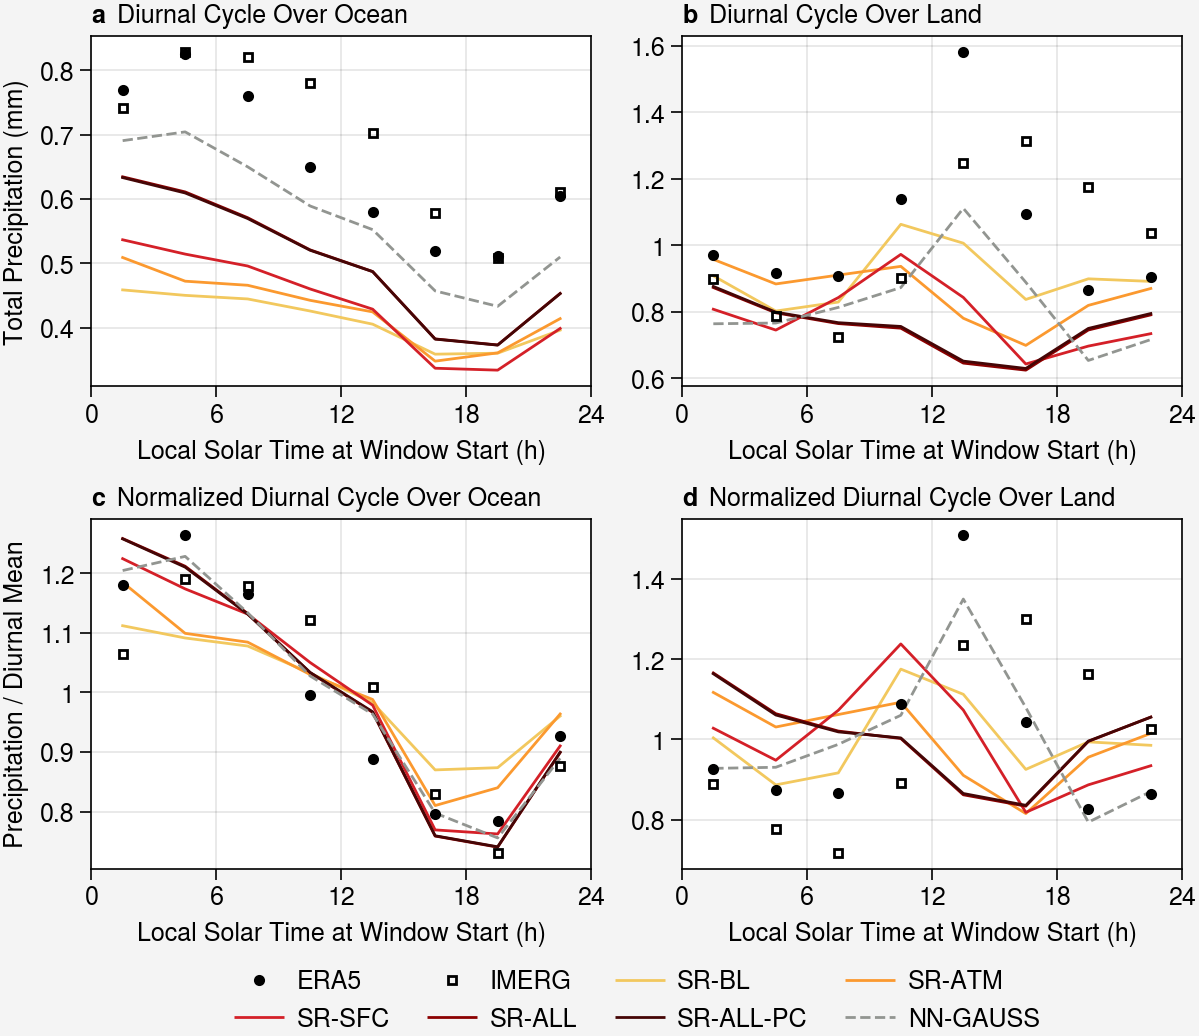

In [7]:
handles  = [Line2D([],[],label=label,**style) for label,style in OBSINFO.values()]
handles += [Line2D([],[],color=MODELINFO[name][1],linestyle=MODELINFO[name][2],linewidth=1,label=MODELINFO[name][0]) for name in predtp]

fig,axs = pplt.subplots(nrows=2,ncols=2,refwidth=2.5,refheight=1.75,share=False)
for col,region in enumerate(REGIONS):
    mask = regionmasks[region]
    for name,(_,style) in OBSINFO.items():
        cycle = bin_by_hour(hourbin,obstp[name],mask)
        axs[0,col].plot(hourcenters,cycle,zorder=3,**style)
        axs[1,col].plot(hourcenters,cycle/cycle.mean(),zorder=3,**style)
    for name,values in predtp.items():
        _,color,linestyle = MODELINFO[name]
        cycle = bin_by_hour(hourbin,values,mask)
        axs[0,col].plot(hourcenters,cycle,color=color,linestyle=linestyle,linewidth=1)
        axs[1,col].plot(hourcenters,cycle/cycle.mean(),color=color,linestyle=linestyle,linewidth=1)
    axs[0,col].format(title=f'Diurnal Cycle Over {region}')
    axs[1,col].format(title=f'Normalized Diurnal Cycle Over {region}')
axs[0,0].format(ylabel='Total Precipitation (mm)')
axs[1,0].format(ylabel='Precipitation / Diurnal Mean')
fig.legend(handles,loc='b',ncols=4,frame=False)
axs.format(xlabel='Local Solar Time at Window Start (h)',xlim=(0,24),xticks=6,abc=True,titleloc='l')
pplt.show()

In [8]:
rows = []
for ref in OBSINFO:
    for region in REGIONS:
        mask     = regionmasks[region]
        refcycle = bin_by_hour(hourbin,obstp[ref],mask)
        refpeak  = peakbins[ref][gridmasks[region]]
        for name,values in alltp.items():
            if name==ref:
                continue
            cycle = bin_by_hour(hourbin,values,mask)
            peak  = peakbins[name][gridmasks[region]]
            valid = np.isfinite(peak)&np.isfinite(refpeak)
            rows.append({'Reference':get_label(ref),
                         'Region':region,
                         'Model':get_label(name),
                         'Mean Bias (mm)':cycle.mean()-refcycle.mean(),
                         'Amplitude Ratio':np.ptp(cycle)/np.ptp(refcycle),
                         'Normalized Amplitude Ratio':(np.ptp(cycle)/cycle.mean())/(np.ptp(refcycle)/refcycle.mean()),
                         'Correlation':np.corrcoef(cycle,refcycle)[0,1],
                         'Peak Hour (h)':hourcenters[np.argmax(cycle)],
                         'Reference Peak Hour (h)':hourcenters[np.argmax(refcycle)],
                         'Grid Peak Within 3 h (%)':100*np.mean(calc_bin_distance(peak[valid],refpeak[valid])<=1)})
display(pd.DataFrame(rows).style.hide(axis='index').format(precision=2))

Reference,Region,Model,Mean Bias (mm),Amplitude Ratio,Normalized Amplitude Ratio,Correlation,Peak Hour (h),Reference Peak Hour (h),Grid Peak Within 3 h (%)
ERA5,Ocean,IMERG,0.04,1.02,0.96,0.88,4.50,4.50,56.89
ERA5,Ocean,SR-BL,-0.24,0.32,0.50,0.95,1.50,4.50,70.24
ERA5,Ocean,SR-ATM,-0.22,0.51,0.78,0.91,1.50,4.50,79.21
ERA5,Ocean,SR-SFC,-0.21,0.65,0.96,0.95,1.50,4.50,83.15
ERA5,Ocean,SR-ALL,-0.15,0.83,1.08,0.96,1.50,4.50,81.40
ERA5,Ocean,SR-ALL-PC,-0.15,0.83,1.08,0.96,1.50,4.50,81.40
ERA5,Ocean,NN-GAUSS,-0.08,0.86,0.98,0.97,4.50,4.50,82.93
ERA5,Land,IMERG,-0.04,0.82,0.85,0.48,16.50,13.50,65.46
ERA5,Land,SR-BL,-0.14,0.36,0.42,0.62,10.50,13.50,78.35
ERA5,Land,SR-ATM,-0.19,0.36,0.44,-0.38,1.50,13.50,48.45


In [9]:
rows = []
for name in ['era5',*TABLEMODELS]:
    row = {'Model':get_label(name)}
    for region in REGIONS:
        mask      = regionmasks[region]
        era5cycle = bin_by_hour(hourbin,tp,mask)
        cycle     = bin_by_hour(hourbin,alltp[name],mask)
        model     = name!='era5'
        row[(region,'R2')]        = calc_r2(alltp[name],tp,mask) if model else np.nan
        row[(region,'Range')]     = 100*np.ptp(cycle)/np.ptp(era5cycle)
        row[(region,'r')]         = np.corrcoef(cycle,era5cycle)[0,1] if model else np.nan
        row[(region,'Peak')]      = hourcenters[np.argmax(cycle)]
    rows.append(row)
table = pd.DataFrame(rows).set_index('Model')
table.columns = pd.MultiIndex.from_tuples(table.columns)
display(table.style.format(lambda value:'--' if np.isnan(value) else f'{value:.3f}'))
for model,values in table.iterrows():
    formats = {'R2':'{:.3f}','Range':'{:.0f}','r':'{:.2f}'}
    entries = [format_bin(value) if column[1]=='Peak' else ('--' if np.isnan(value) else formats[column[1]].format(value)) for column,value in values.items()]
    print(' & '.join([model,*entries])+' \\\\')

ERA5 & -- & 100 & -- & 03--06 & -- & 100 & -- & 12--15 \\
SR-ATM & 0.351 & 51 & 0.91 & 00--03 & 0.302 & 36 & -0.38 & 00--03 \\
SR-SFC & 0.434 & 65 & 0.95 & 00--03 & 0.304 & 46 & 0.36 & 09--12 \\
SR-ALL & 0.509 & 83 & 0.96 & 00--03 & 0.293 & 35 & -0.63 & 00--03 \\
SR-ALL-PC & 0.509 & 83 & 0.96 & 00--03 & 0.294 & 34 & -0.62 & 00--03 \\


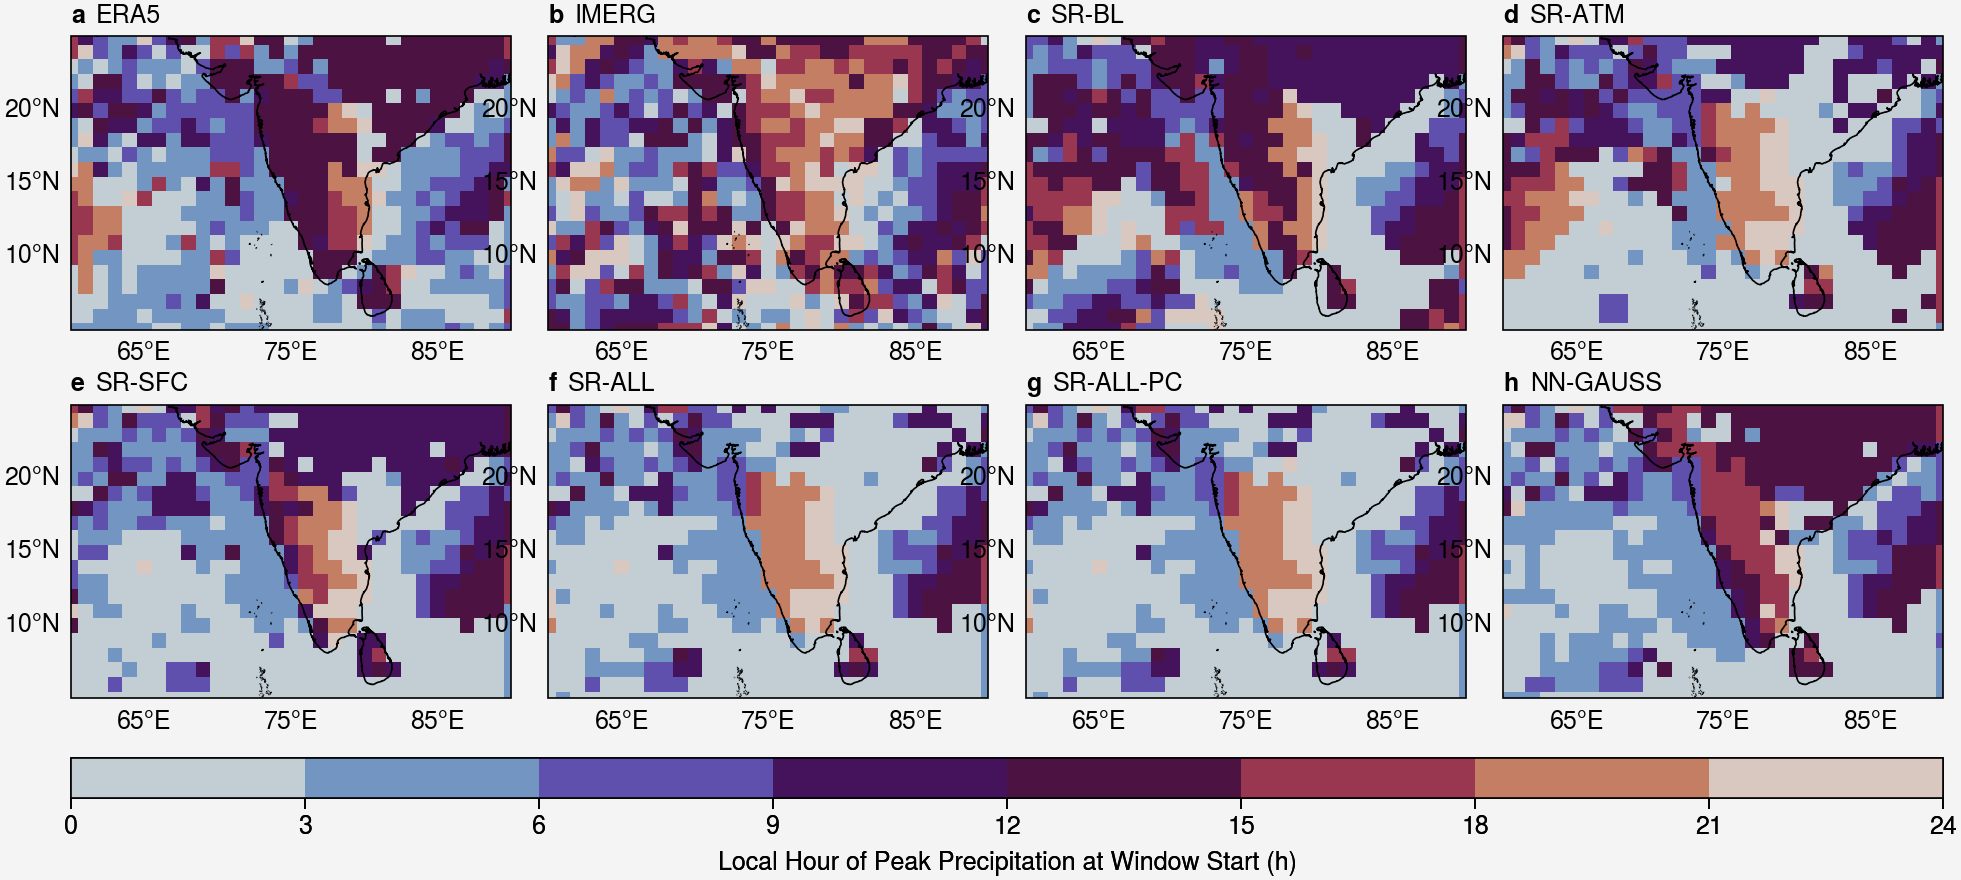

In [10]:
panels = [*OBSINFO,*predtp]
fig,axs = pplt.subplots(nrows=2,ncols=4,proj='cyl',refwidth=2.2,wspace=1.5,hspace=3)
for ax,name in zip(axs,panels):
    peakhour = ((peakbins[name]+0.5)*24/NHOURBINS).reshape(nlat,nlon)
    m = ax.pcolormesh(lon,lat,peakhour,cmap='twilight',vmin=0,vmax=24,levels=NHOURBINS)
    format_map(ax,get_label(name))
fig.colorbar(m,loc='b',ticks=3,label='Local Hour of Peak Precipitation at Window Start (h)')
axs.format(abc=True,titleloc='l')
pplt.show()

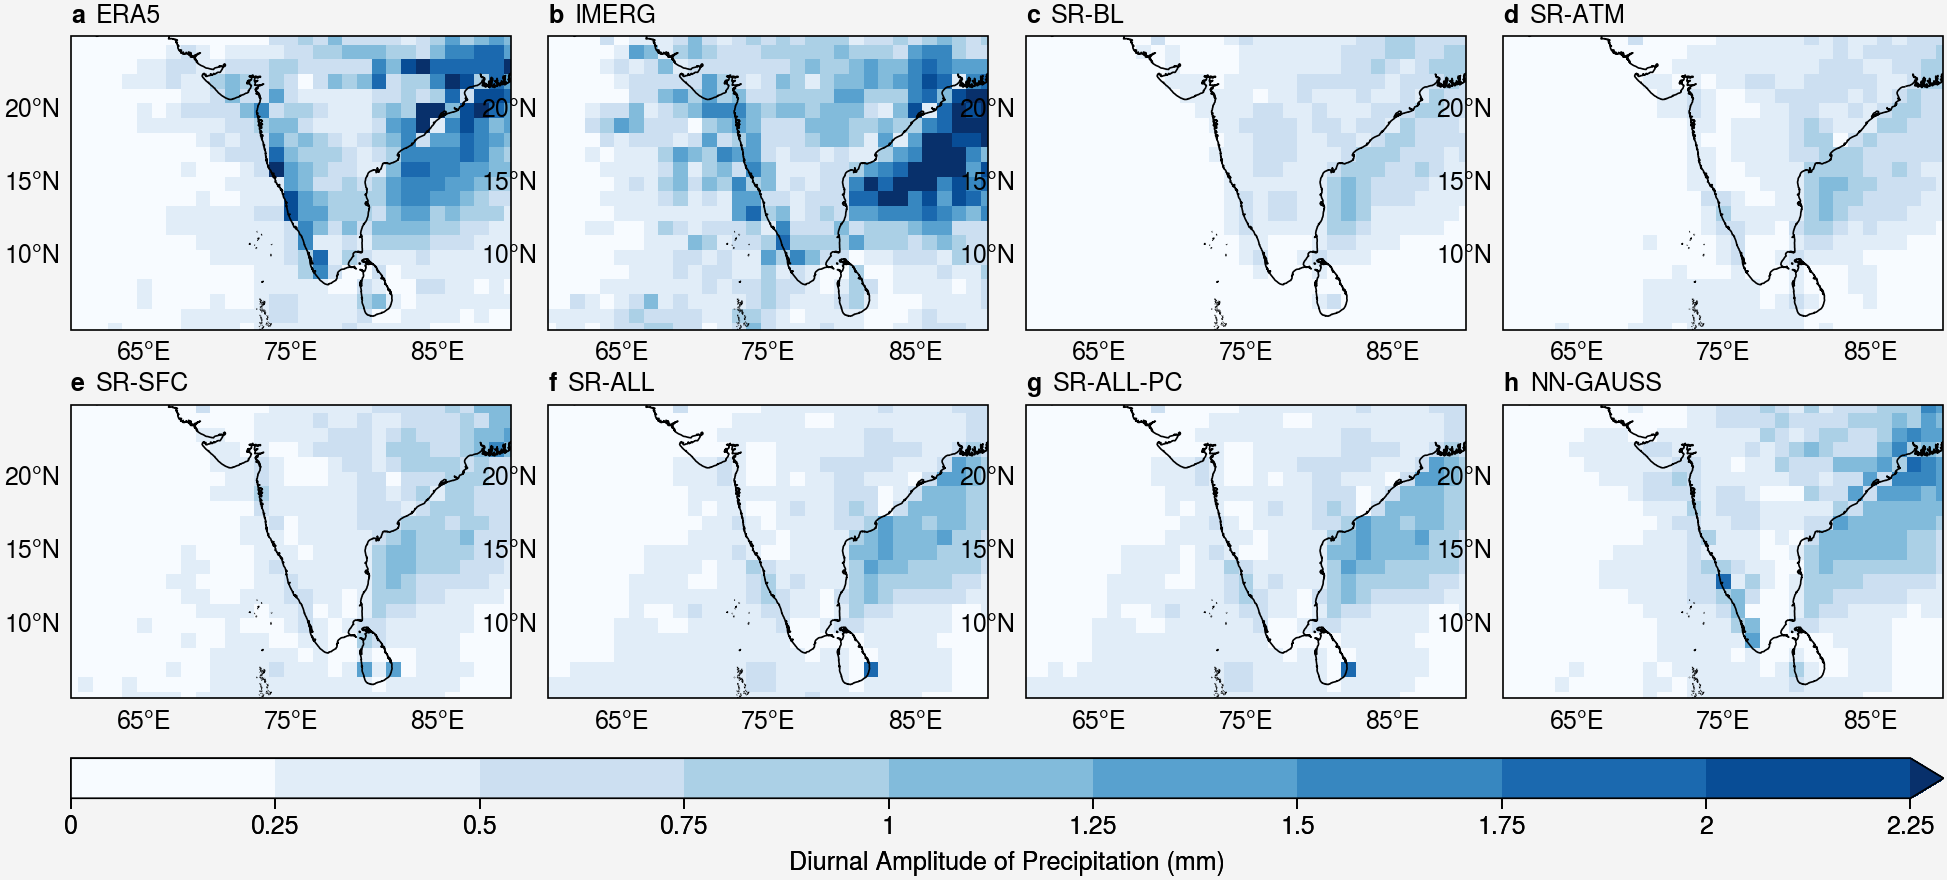

In [11]:
amplitudes = {name:(np.nanmax(composite,axis=0)-np.nanmin(composite,axis=0)).reshape(nlat,nlon) for name,composite in composites.items()}
amplim     = np.nanpercentile(np.concatenate([amplitudes[name].ravel() for name in OBSINFO]),98)
fig,axs = pplt.subplots(nrows=2,ncols=4,proj='cyl',refwidth=2.2,wspace=1.5,hspace=3)
for ax,name in zip(axs,panels):
    m = ax.pcolormesh(lon,lat,amplitudes[name],cmap='Blues',vmin=0,vmax=amplim,levels=10,extend='max')
    format_map(ax,get_label(name))
fig.colorbar(m,loc='b',label='Diurnal Amplitude of Precipitation (mm)')
axs.format(abc=True,titleloc='l')
pplt.show()

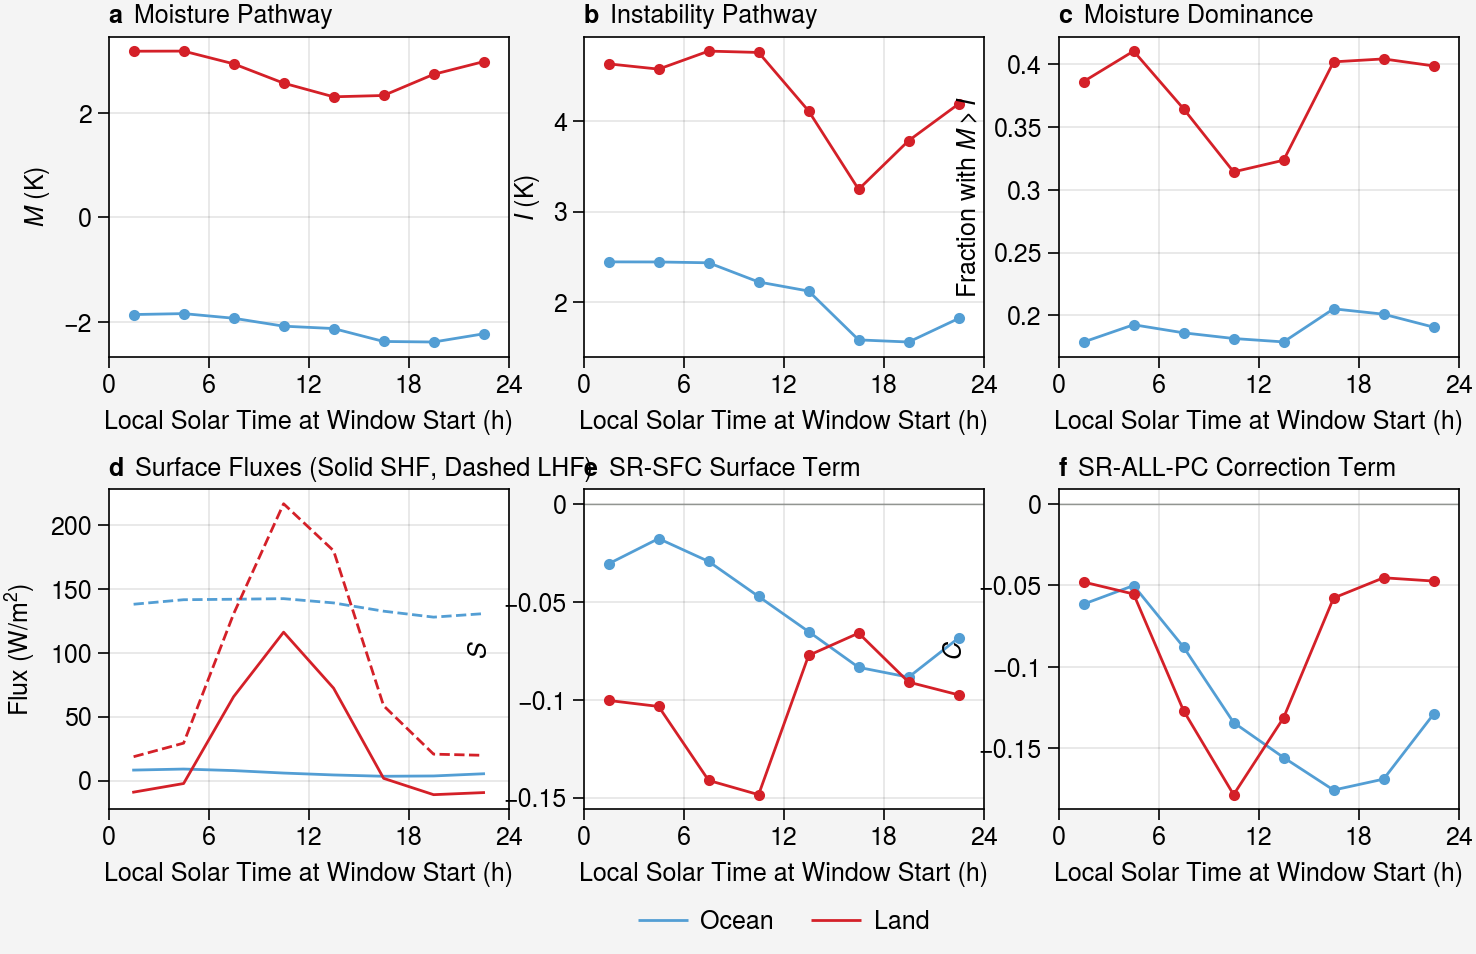

Ocean: diurnal range of mean M = 0.54 K, mean I = 0.88 K
Land: diurnal range of mean M = 0.87 K, mean I = 1.52 K


In [12]:
fig,axs = pplt.subplots(nrows=2,ncols=3,refwidth=2,refheight=1.6,share=False,wspace=3)
for region,color in REGIONS.items():
    mask = regionmasks[region]
    axs[0].plot(hourcenters,bin_by_hour(hourbin,moisture,mask),color=color,linewidth=1,marker='o',markersize=3)
    axs[1].plot(hourcenters,bin_by_hour(hourbin,instability,mask),color=color,linewidth=1,marker='o',markersize=3)
    axs[2].plot(hourcenters,bin_by_hour(hourbin,(moisture>instability).astype(float),mask),color=color,linewidth=1,marker='o',markersize=3)
    axs[3].plot(hourcenters,bin_by_hour(hourbin,shf,mask),color=color,linewidth=1)
    axs[3].plot(hourcenters,bin_by_hour(hourbin,lhf,mask),color=color,linewidth=1,linestyle='--')
    axs[4].plot(hourcenters,bin_by_hour(hourbin,surface,mask),color=color,linewidth=1,marker='o',markersize=3)
    axs[5].plot(hourcenters,bin_by_hour(hourbin,correction,mask),color=color,linewidth=1,marker='o',markersize=3)
for ax in axs[4:]:
    ax.axhline(0,color='gray',linewidth=0.5)
axs[0].format(title='Moisture Pathway',ylabel='$\\mathit{M}$ (K)')
axs[1].format(title='Instability Pathway',ylabel='$\\mathit{I}$ (K)')
axs[2].format(title='Moisture Dominance',ylabel='Fraction with $\\mathit{M} > \\mathit{I}$')
axs[3].format(title='Surface Fluxes (Solid SHF, Dashed LHF)',ylabel='Flux (W/m$^2$)')
axs[4].format(title='SR-SFC Surface Term',ylabel='$\\mathit{S}$')
axs[5].format(title='SR-ALL-PC Correction Term',ylabel='$\\mathit{C}$')
fig.legend([Line2D([],[],color=color,linewidth=1,label=region) for region,color in REGIONS.items()],loc='b',ncols=2,frame=False)
axs.format(xlabel='Local Solar Time at Window Start (h)',xlim=(0,24),xticks=6,abc=True,titleloc='l')
pplt.show()
for region in REGIONS:
    mask = regionmasks[region]
    print(f'{region}: diurnal range of mean M = {np.ptp(bin_by_hour(hourbin,moisture,mask)):.2f} K, mean I = {np.ptp(bin_by_hour(hourbin,instability,mask)):.2f} K')